<a href="https://colab.research.google.com/github/avijitpsingh/iitd-assignments/blob/main/IITD_PGDACEQAI_01_Team_No_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IITD_PGDACEQAI_01 - Team No. 05
## Part A - Path Loss Modeling and Coverage Estimation
## Part B - Quantum Teleportation with Fidelity Evaluation
---


# PART A - Path loss modeling & coverage estimation

---

**Free Space Path Loss (FSPL):**
PL(dB) = 20log10(d) + 20log10(f) + 32.44

**Log-Distance Model:**
PL(d) = PL(d0) + 10n log10(d/d0)

---


In [56]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

In [57]:
# Free Space Path Loss Function
def free_space_path_loss(d_km, f_MHz):
    """Compute Free Space Path Loss in dB"""
    return 20*np.log10(d_km) + 20*np.log10(f_MHz) + 32.44

In [58]:
# Log-Distance Path Loss Model
def log_distance_model(d_km, d0_km, f_MHz, n):
    """Compute Log-Distance Path Loss in dB"""
    PL_d0 = free_space_path_loss(d0_km, f_MHz)
    return PL_d0 + 10*n*np.log10(d_km/d0_km)

## Simulation 1: Free-Space Path Loss vs Distance for Different Frequencies

This simulation evaluates the Free-Space Path Loss (FSPL) model for different carrier frequencies (900 MHz, 2.4 GHz, and 28 GHz) as a function of distance. The results show that path loss increases logarithmically with distance and is significantly higher at larger frequencies, illustrating why lower-frequency signals provide better coverage.

In [59]:
# Define simulation parameters
d = np.linspace(0.001, 2, 1000)  # Distance from 1m to 2km
frequencies = [900, 2400, 28000]  # Frequencies in MHz
Pt = 30  # Transmit power in dBm
Pr_min = -90  # Receiver sensitivity in dBm

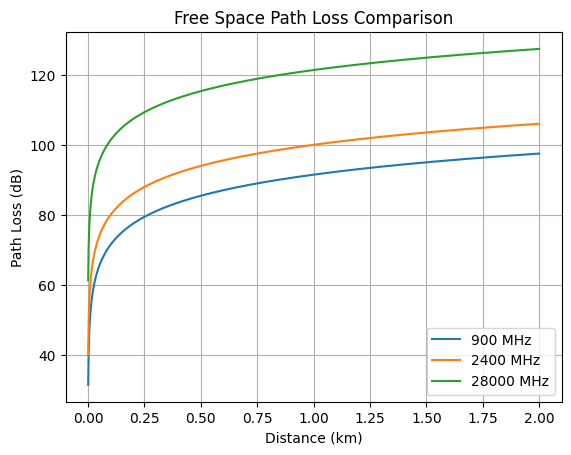

In [60]:
# Plot FSPL for different frequencies
plt.figure()
# Loop through each frequency defined earlier
for f in frequencies:
    # Calculate Free Space Path Loss for the current frequency
    PL = free_space_path_loss(d, f)
    # Plot the path loss against distance for the current frequency
    plt.plot(d, PL, label=f"{f} MHz")
# Set the x-axis label
plt.xlabel('Distance (km)')
# Set the y-axis label
plt.ylabel('Path Loss (dB)')
# Set the title of the plot
plt.title('Free Space Path Loss Comparison')
# Display the legend to differentiate frequencies
plt.legend()
# Add a grid for better readability
plt.grid(True)
# Show the plot
plt.show()

## Simulation 2: Log-Distance Path Loss Model for Different Frequencies


The log-distance path loss model is simulated to analyze signal attenuation in realistic environments with a path loss exponent n=3.

Compared to ideal free-space propagation, the model demonstrates stronger attenuation due to environmental factors such as buildings and obstacles.

In [61]:
# Compute coverage distance
# Loop through each frequency to calculate its maximum coverage distance
for f in frequencies:
    # Calculate the maximum distance (d_max) for each frequency
    # This formula is derived from the Free Space Path Loss equation (PL = 20log10(d) + 20log10(f) + 32.44)
    # rearranged to solve for d, given Pt (transmit power) and Pr_min (receiver sensitivity).
    # Specifically, Pt - Pr_min = PL, so PL = 20log10(d) + 20log10(f) + 32.44
    # d = 10^((Pt - Pr_min - 20log10(f) - 32.44) / 20)
    d_max = 10 ** ((Pt - Pr_min - 20*np.log10(f) - 32.44) / 20)
    # Print the calculated coverage distance for the current frequency, converted to meters
    print(f"Coverage for {f} MHz: {d_max*1000:.2f} meters")

Coverage for 900 MHz: 26531.24 meters
Coverage for 2400 MHz: 9949.21 meters
Coverage for 28000 MHz: 852.79 meters


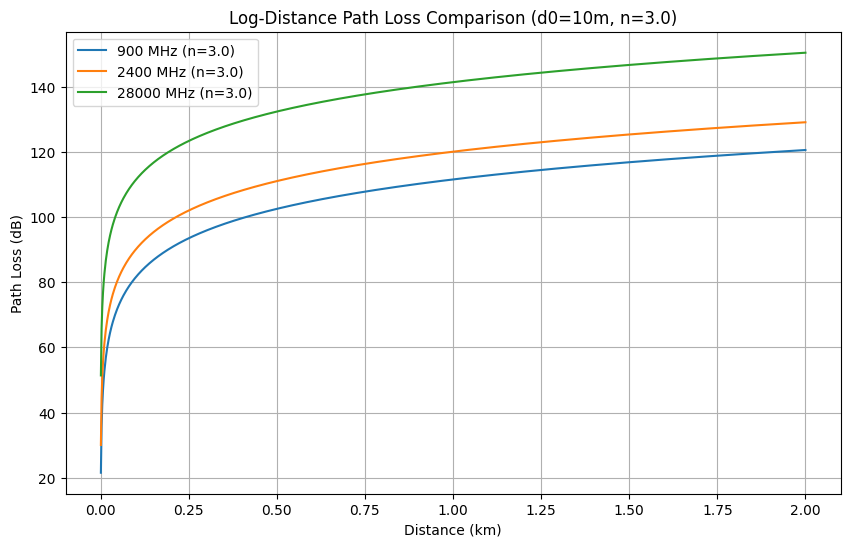

In [62]:
# Define additional parameters for the Log-Distance Model
# Reference distance in km (often 1 km for urban/suburban environments)
d0_km = 0.01  # 10 meters, for example
# Path loss exponent (typically between 2 and 4, depending on environment)
n = 3.0       # Represents a typical urban environment

# Plot Log-Distance Path Loss for different frequencies
plt.figure(figsize=(10, 6))

# Loop through each frequency defined earlier
for f in frequencies:
    # Calculate Log-Distance Path Loss for the current frequency
    PL_log_distance = log_distance_model(d, d0_km, f, n)
    # Plot the path loss against distance for the current frequency
    plt.plot(d, PL_log_distance, label=f"{f} MHz (n={n})")

# Set the x-axis label
plt.xlabel('Distance (km)')
# Set the y-axis label
plt.ylabel('Path Loss (dB)')
# Set the title of the plot
plt.title(f'Log-Distance Path Loss Comparison (d0={d0_km*1000:.0f}m, n={n})')
# Display the legend to differentiate frequencies and path loss exponent
plt.legend()
# Add a grid for better readability
plt.grid(True)
# Show the plot
plt.show()

## Simulation 3: Comparison of Free-Space and Log-Distance Models



This simulation compares the ideal Free-Space Path Loss model with the log-distance model to highlight the impact of environmental propagation effects.

The results show that real-world environments introduce additional attenuation beyond the theoretical free-space prediction.

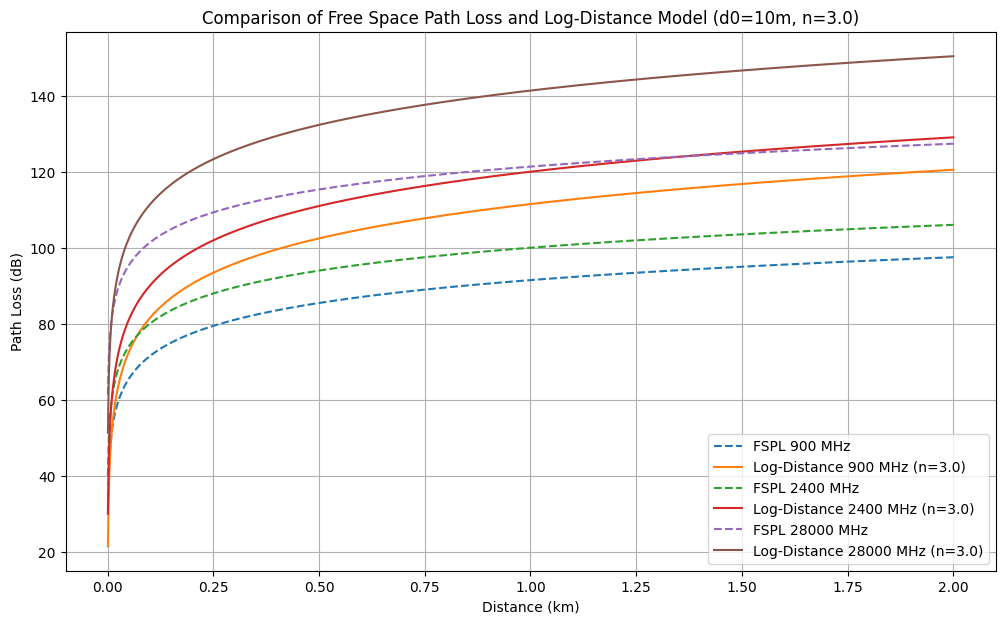

In [63]:
# Define additional parameters for the Log-Distance Model (if not already defined or to ensure consistency)
d0_km = 0.01  # Reference distance in km (e.g., 10 meters)
n = 3.0       # Path loss exponent (e.g., for urban environment)

plt.figure(figsize=(12, 7))

for f in frequencies:
    # Calculate Free Space Path Loss
    PL_fspl = free_space_path_loss(d, f)
    # Calculate Log-Distance Path Loss
    PL_log_distance = log_distance_model(d, d0_km, f, n)

    # Plot both on the same graph
    plt.plot(d, PL_fspl, linestyle='--', label=f'FSPL {f} MHz')
    plt.plot(d, PL_log_distance, linestyle='-', label=f'Log-Distance {f} MHz (n={n})')

plt.xlabel('Distance (km)')
plt.ylabel('Path Loss (dB)')
plt.title(f'Comparison of Free Space Path Loss and Log-Distance Model (d0={d0_km*1000:.0f}m, n={n})')
plt.legend()
plt.grid(True)
plt.show()

## Simulation 4: Effect of Environment (Path Loss Exponent Variation)



This experiment varies the path-loss exponent **n** to represent different propagation environments such as free space, suburban, urban, and indoor scenarios.

The results demonstrate that higher values of
**n** lead to **faster signal attenuation, significantly reducing communication range in dense environments**.

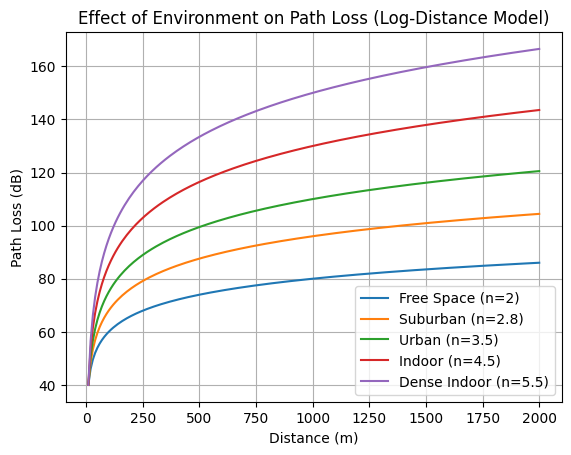

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Define a range of distances from 10 meters to 2000 meters
distance = np.linspace(10, 2000, 200)

# Define reference distance (d0) in meters
d0 = 10
# Define path loss at the reference distance (PL_d0) in dB
PL_d0 = 40

# Define different environments with their corresponding path loss exponents (n)
environments = {
    "Free Space (n=2)": 2,
    "Suburban (n=2.8)": 2.8,
    "Urban (n=3.5)": 3.5,
    "Indoor (n=4.5)": 4.5,
    "Dense Indoor (n=5.5)": 5.5
}

# Loop through each environment and its path loss exponent
for env, n in environments.items():
    # Calculate Path Loss using the Log-Distance Model formula:
    # PL(d) = PL(d0) + 10 * n * log10(d / d0)
    PL = PL_d0 + 10 * n * np.log10(distance / d0)

    # Plot the calculated path loss against distance for the current environment
    plt.plot(distance, PL, label=env)

# Set the x-axis label
plt.xlabel("Distance (m)")
# Set the y-axis label
plt.ylabel("Path Loss (dB)")
# Set the title of the plot
plt.title("Effect of Environment on Path Loss (Log-Distance Model)")

# Display the legend to differentiate environments
plt.legend()
# Add a grid for better readability
plt.grid()

# Show the plot
plt.show()

## Simulation 5: Coverage Estimation Using Free-Space and Log-Distance Models

This simulation estimates the communication coverage range by calculating the received power as a function of distance using both the free-space and log-distance propagation models. The intersection with the receiver sensitivity threshold determines the maximum communication distance

Free-Space Coverage Radius: 3144.4 m
Log-Distance Coverage Radius: 461.1 m


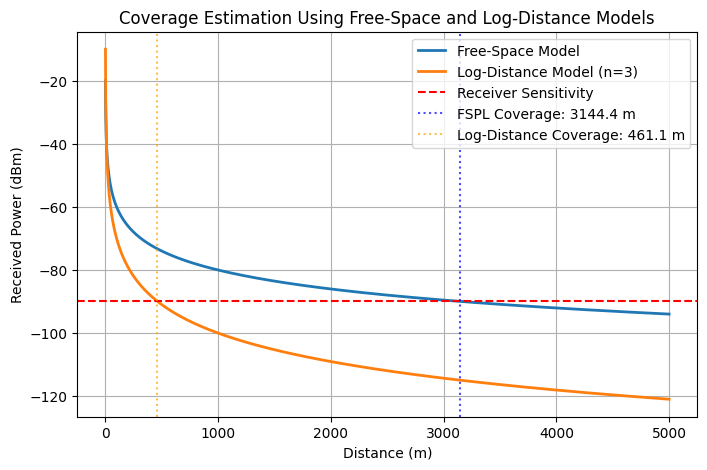

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# System Parameters
# -----------------------------

Pt = 20          # Transmit power in dBm (decibel-milliwatts)
sensitivity = -90 # Receiver sensitivity in dBm (minimum power required for detection)

f = 2.4e9        # Carrier frequency in Hz (2.4 GHz, a common ISM band frequency)

# Define a range of distances from 1 meter to 5000 meters for simulation
distance = np.linspace(1, 5000, 2000)

# -----------------------------
# Unit Conversion
# -----------------------------

distance_km = distance / 1000     # Convert distance from meters to kilometers
f_mhz = f / 1e6                   # Convert frequency from Hz to MHz

# -----------------------------
# Free Space Path Loss (FSPL) Model
# -----------------------------

# Calculate Free Space Path Loss using the formula:
# PL(dB) = 20*log10(d_km) + 20*log10(f_mhz) + 32.44
PL_fs = 20*np.log10(distance_km) + 20*np.log10(f_mhz) + 32.44

# Calculate Received Power for the FSPL model
# Pr = Pt - PL
Pr_fs = Pt - PL_fs


# -----------------------------
# Log-Distance Model
# -----------------------------

d0 = 10       # Reference distance in meters (e.g., 10 meters)
n = 3         # Path loss exponent (e.g., 3 for a typical urban environment)

# Calculate Path Loss at the reference distance (d0) using FSPL formula for consistency
# Convert d0 to km for the FSPL formula part
PL_d0 = 20*np.log10(d0/1000) + 20*np.log10(f_mhz) + 32.44

# Calculate Log-Distance Path Loss using the formula:
# PL(d) = PL(d0) + 10*n*log10(d/d0)
PL_log = PL_d0 + 10*n*np.log10(distance/d0)

# Calculate Received Power for the Log-Distance model
Pr_log = Pt - PL_log


# -----------------------------
# Coverage Radius Calculation
# -----------------------------

# Find the index where the received power crosses the receiver sensitivity threshold
# We take the last index where Pr >= sensitivity, indicating the maximum coverage distance
fs_index = np.where(Pr_fs >= sensitivity)[0][-1]
log_index = np.where(Pr_log >= sensitivity)[0][-1]

# Determine the coverage distance corresponding to these indices
coverage_fs = distance[fs_index]
coverage_log = distance[log_index]

# Print the calculated coverage radii for both models
print("Free-Space Coverage Radius: {:.1f} m".format(coverage_fs))
print("Log-Distance Coverage Radius: {:.1f} m".format(coverage_log))


# -----------------------------
# Plotting the Results
# -----------------------------

plt.figure(figsize=(8,5))

# Plot Received Power for Free-Space Model
plt.plot(distance, Pr_fs, label="Free-Space Model", linewidth=2)
# Plot Received Power for Log-Distance Model
plt.plot(distance, Pr_log, label="Log-Distance Model (n=3)", linewidth=2)

# Add a horizontal line representing the receiver sensitivity threshold
plt.axhline(sensitivity, color='red', linestyle='--', label="Receiver Sensitivity")

# Add vertical lines to mark the calculated coverage radii on the plot
plt.axvline(coverage_fs, linestyle=":", color="blue", alpha=0.7, label=f'FSPL Coverage: {coverage_fs:.1f} m')
plt.axvline(coverage_log, linestyle=":", color="orange", alpha=0.7, label=f'Log-Distance Coverage: {coverage_log:.1f} m')

plt.xlabel("Distance (m)")  # X-axis label
plt.ylabel("Received Power (dBm)") # Y-axis label
plt.title("Coverage Estimation Using Free-Space and Log-Distance Models") # Plot title

plt.legend() # Display legend for all plotted lines
plt.grid()   # Add a grid for better readability

plt.show()   # Show the generated plot

# PART B - Quantum teleportation protocol with fidelity evaluation

---

Quantum teleportation transfers an unknown quantum state using entanglement.
Fidelity measures closeness between original and teleported state.


In [66]:
# Install qiskit, qiskit-aer qutip (required if env doest have it installed)
!pip install qiskit qiskit-aer qutip --quiet

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

## Discrete-Variable (DV) Teleportation

* Implementation of the Bennett protocol using density
matrices.
* Noise is modeled using a depolarizing channel.


In [68]:
def dv_teleportation_output(alpha, beta, noise_prob=0):
    """
    Simulates quantum teleportation and calculates its fidelity with optional noise.

    The function prepares an arbitrary single-qubit state (alpha|0> + beta|1>),
    performs a standard quantum teleportation protocol, and then measures the
    fidelity between the original state and the teleported state on the third qubit.
    Noise can be introduced into the simulation as depolarizing errors.

    Args:
        alpha (float): The amplitude of the |0> state in the initial quantum state.
                       Must satisfy alpha^2 + beta^2 = 1.
        beta (float): The amplitude of the |1> state in the initial quantum state.
                      Must satisfy alpha^2 + beta^2 = 1.
        noise_prob (float, optional): The probability of depolarizing error on single
                                      and two-qubit gates. Defaults to 0 (no noise).

    Returns:
        tuple: A tuple containing:
            - float: The fidelity between the original quantum state and the teleported state.
            - qiskit.quantum_info.operators.operator.Operator: The input density matrix.
            - qiskit.quantum_info.states.densitymatrix.DensityMatrix: The teleported density matrix on Bob's qubit.
    """
    qc = QuantumCircuit(3)

    # Input pure state density matrix
    rho_input = Statevector([alpha, beta]).to_operator()

    # Prepare the initial state to be teleported (qubit 0)
    # For a state alpha|0> + beta|1> with alpha, beta real, an Ry gate can prepare it.
    # alpha = cos(theta/2), beta = sin(theta/2) => theta = 2 * arccos(alpha)
    # qc.initialize([alpha, beta], 0) # Original line causing the error
    theta = 2 * np.arccos(alpha)
    qc.ry(theta, 0)

    # Create an entangled Bell pair between qubit 1 (Alice) and qubit 2 (Bob)
    qc.h(1)
    qc.cx(1,2)

    # Alice's operations for teleportation
    # CNOT from the state to be teleported (q0) to Alice's entangled qubit (q1)
    qc.cx(0,1)
    # Hadamard on the state to be teleported (q0)
    qc.h(0)

    # Bob's operations (classical corrections based on Alice's implicit measurements)
    # CNOT on Bob's qubit (q2) controlled by Alice's entangled qubit (q1)
    qc.cx(1,2)
    # CZ on Bob's qubit (q2) controlled by the state to be teleported (q0)
    qc.cz(0,2)

    # Save the density matrix of the final state for fidelity calculation
    qc.save_density_matrix()

    # Initialize noise model if noise_prob is greater than 0
    noise_model = None
    if noise_prob > 0:
        noise_model = NoiseModel()
        # Define depolarizing error for single-qubit gates
        error_1q = depolarizing_error(noise_prob, 1)
        # Define depolarizing error for two-qubit gates
        error_2q = depolarizing_error(noise_prob, 2)
        # Add these errors to the noise model for relevant gates
        noise_model.add_all_qubit_quantum_error(error_1q, ['h','x','z','ry'])
        noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

    # Initialize AerSimulator with density_matrix method and optional noise model
    simulator = AerSimulator(method='density_matrix', noise_model=noise_model)
    # Run the circuit on the simulator. shots=1 is sufficient for density_matrix method.
    result = simulator.run(qc, shots=1).result()

    # Extract the full density matrix from the simulation results
    dm_full = DensityMatrix(result.data()['density_matrix'].data)
    # Perform a partial trace to get the density matrix of Bob's qubit (q2),
    # which now holds the teleported state. Tracing out qubits 0 and 1.
    return partial_trace(dm_full, [0,1])

## Simulation 1:  Fidelity vs. Noise

We simulated the Bennett protocol under varying depolarizing noise
probabilities.The results clearly demonstrated that as noise increases, the teleportation fidelity decreases, eventually falling below the classical limit of 2/3.


This highlights the vulnerability of quantum communication to environmental decoherence.

In [69]:
def compute_fidelity(alpha, beta, rho_out):
    """
    Computes the fidelity between an initial pure quantum state and a final density matrix.

    Args:
        alpha (float): Amplitude of the |0> component of the initial state.
        beta (float): Amplitude of the |1> component of the initial state.
        rho_out (DensityMatrix): The density matrix of the teleported or final state.

    Returns:
        float: The fidelity between the initial pure state and the final state.
    """
    # Create a Statevector object for the input pure state from alpha and beta
    rho_in = Statevector([alpha, beta])
    # Calculate and return the fidelity between the input pure state and the output density matrix
    return state_fidelity(rho_in, rho_out)

In [70]:
def run_noise_sweep(alpha, beta, noise_probs):
    """
    Runs teleportation over a range of noise probabilities
    and returns the fidelity results.
    """

    fidelities = []

    for p in noise_probs:
        rho_out = dv_teleportation_output(alpha, beta, p)
        F = compute_fidelity(alpha, beta, rho_out)
        fidelities.append(F)

    return fidelities

In [71]:
def plot_fidelity_vs_noise(noise_probs, fidelities):
    """
    Plot teleportation fidelity vs noise probability with
    classical threshold and quantum advantage visualization.
    """

    plt.figure(figsize=(8,5))

    # Plot teleportation fidelity curve
    plt.plot(noise_probs, fidelities, marker='o', linewidth=2, label="Teleportation Fidelity")

    # Classical fidelity threshold for qubit teleportation
    classical_limit = 2/3
    plt.axhline(classical_limit, linestyle="--", color="red", label="Classical Limit (2/3)")

    # Shade quantum advantage region
    plt.fill_between(noise_probs, classical_limit, 1, alpha=0.1, color="green",
                     label="Quantum Advantage Region")

    # Detect threshold where fidelity crosses classical limit
    threshold_noise = None
    for i in range(len(fidelities)):
        if fidelities[i] < classical_limit:
            threshold_noise = noise_probs[i]
            break

    # Highlight threshold point if detected
    if threshold_noise is not None:
        plt.axvline(threshold_noise, linestyle=":", color="purple",
                    label=f"Noise Threshold ≈ {threshold_noise:.3f}")

    # Labels and formatting
    plt.xlabel("Noise Probability")
    plt.ylabel("Teleportation Fidelity")
    plt.title("DV Quantum Teleportation Fidelity vs Noise")

    plt.ylim(0,1.05)

    plt.grid(True)
    plt.legend()

    plt.show()

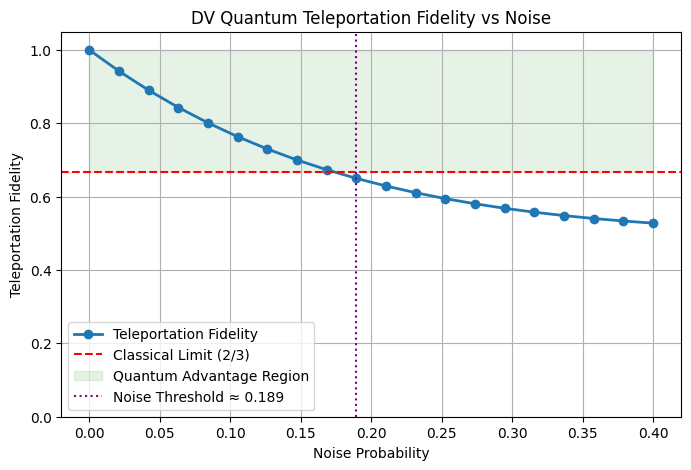

In [72]:
alpha = 1/np.sqrt(3)
beta = np.sqrt(2/3)

noise_probs = np.linspace(0, 0.4, 20)
fidelities = run_noise_sweep(alpha, beta, noise_probs)

plot_fidelity_vs_noise(noise_probs, fidelities)

In [73]:

# Capture rho_input and dm_q2 for Bloch sphere visualization for a specific case (e.g., noiseless)
# This is done separately to avoid cluttering the fidelity sweep loop and ensure these variables are globally available.
rho_input_global = Statevector([alpha, beta]).to_operator()
dm_q2_global = dv_teleportation_output(alpha, beta, noise_prob=0)

## Simulation 2: Density Matrix Visualization:


We displayed the real parts of the input and teleported density matrices, showing their close resemblance in a noiseless scenario, indicating high fidelity state transfer.


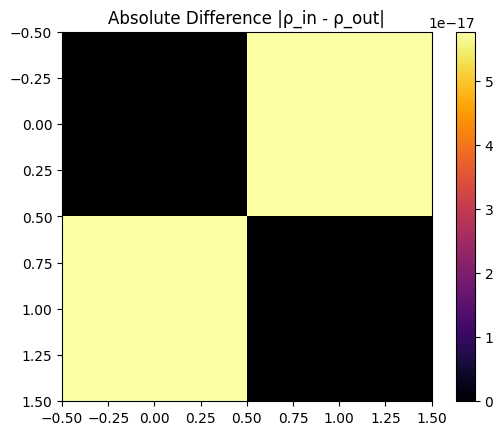

In [74]:
rho_diff = rho_input_global.data - dm_q2_global.data

plt.imshow(np.abs(rho_diff), cmap='inferno')
plt.colorbar()
plt.title("Absolute Difference |ρ_in - ρ_out|")
plt.show()

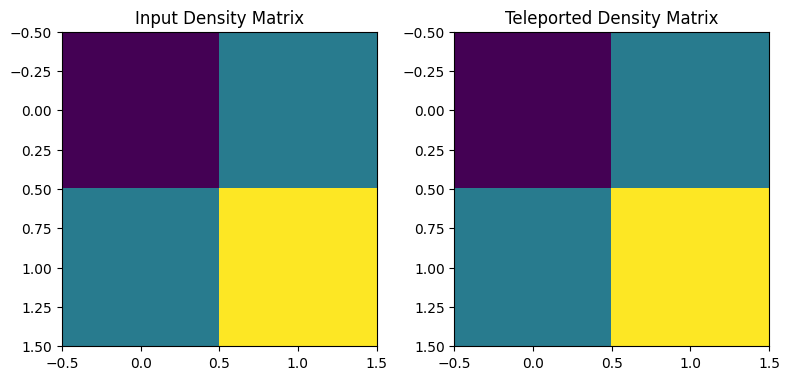

In [75]:
fig, axes = plt.subplots(1,2, figsize=(8,4))

# Display the real part of the input density matrix on the first subplot
axes[0].imshow(np.real(rho_input_global.data), cmap='viridis')
axes[0].set_title("Input Density Matrix")

# Display the real part of the teleported density matrix on the second subplot
axes[1].imshow(np.real(dm_q2_global.data), cmap='viridis')
axes[1].set_title("Teleported Density Matrix")

plt.tight_layout()
# Show the plot
plt.show()

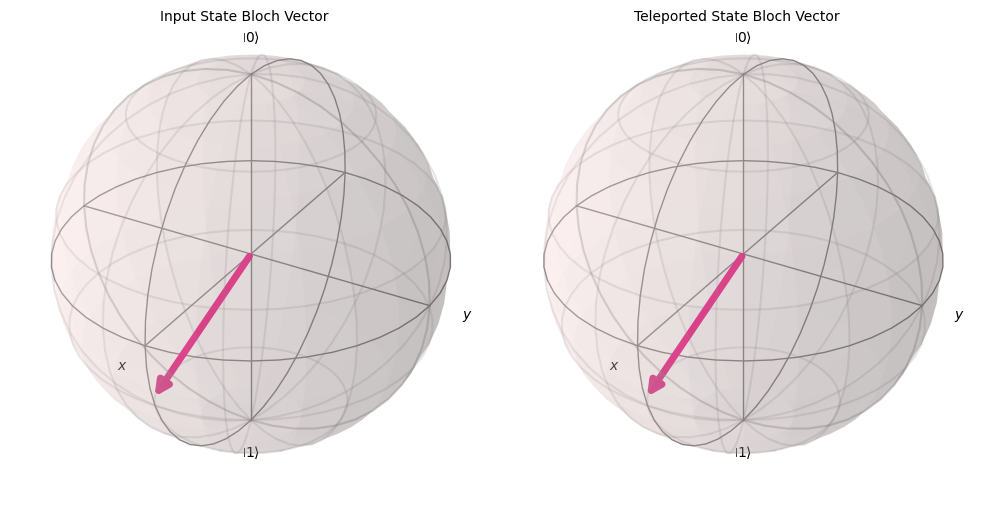

In [76]:
from qiskit.visualization import plot_bloch_vector
import numpy as np
import matplotlib.pyplot as plt

def bloch_vector_from_density(rho):
    rho = rho.data
    x = 2 * np.real(rho[0,1])
    y = 2 * np.imag(rho[1,0])
    z = np.real(rho[0,0] - rho[1,1])
    return [x, y, z]

bloch_input = bloch_vector_from_density(rho_input_global)
bloch_output = bloch_vector_from_density(dm_q2_global)

fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d') # 1 row, 2 columns, 1st plot
plot_bloch_vector(bloch_input, title="Input State Bloch Vector", ax=ax1)

ax2 = fig.add_subplot(1, 2, 2, projection='3d') # 1 row, 2 columns, 2nd plot
plot_bloch_vector(bloch_output, title="Teleported State Bloch Vector", ax=ax2)

plt.tight_layout()
plt.show()

## Simulation 3: Random-State Fidelity Distribution

By teleporting numerous random qubit states, we confirmed the universality of the protocol.

**In a noiseless environment, the fidelity distribution clustered near unity, verifying that the protocol works for arbitrary input states.**

In [77]:
def generate_random_qubit():
    """
    Generate a random qubit state uniformly on the Bloch sphere.
    """

    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2*np.pi)

    alpha = np.cos(theta/2)
    beta = np.exp(1j*phi) * np.sin(theta/2)

    return alpha, beta

In [78]:
def run_random_state_experiment(num_states=100, noise_prob=0):
    """
    Teleport many random states and collect fidelities.
    """

    fidelities = []

    for _ in range(num_states):

        alpha, beta = generate_random_qubit()

        rho_out = dv_teleportation_output(alpha, beta, noise_prob)

        F = compute_fidelity(alpha, beta, rho_out)

        fidelities.append(F)

    return fidelities

In [79]:
def plot_random_state_fidelity(fidelities):

    plt.figure(figsize=(8,5))

    plt.hist(fidelities, bins=15, edgecolor="black", alpha=0.7)

    classical_limit = 2/3
    plt.axvline(classical_limit, linestyle="--", color="red",
                label="Classical Limit (2/3)")

    plt.xlabel("Teleportation Fidelity")
    plt.ylabel("Number of States")
    plt.title("Random-State Teleportation Fidelity Distribution")

    plt.legend()
    plt.grid(True)

    plt.show()

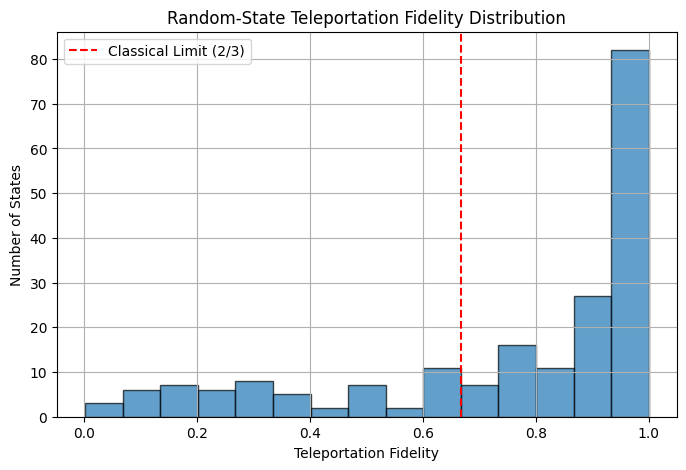

In [80]:
num_states = 200

fidelities = run_random_state_experiment(num_states=num_states, noise_prob=0)

plot_random_state_fidelity(fidelities)

## Simulation 4: Bloch Sphere Visualization

We visualized the Bloch vectors of input and teleported states. In the noiseless case, teleported states perfectly overlapped input states.

When noise was introduced (e.g., noise_prob=0.1), the teleported states deviated from the original input states, with lines connecting them illustrating the impact of noise on the quantum state.

In [81]:
def bloch_vector_from_density(rho):
    """
    Convert a density matrix into Bloch vector coordinates.
    """

    rho = rho.data

    x = 2 * np.real(rho[0,1])
    y = 2 * np.imag(rho[1,0])
    z = np.real(rho[0,0] - rho[1,1])

    return np.array([x, y, z])

In [82]:
def generate_bloch_grid(num_theta=8, num_phi=16):
    """
    Generate qubit states covering the Bloch sphere.
    """

    states = []

    for theta in np.linspace(0, np.pi, num_theta):
        for phi in np.linspace(0, 2*np.pi, num_phi):

            alpha = np.cos(theta/2)
            beta = np.exp(1j * phi) * np.sin(theta/2)

            states.append((alpha, beta))

    return states

In [83]:
def run_bloch_teleportation_map(noise_prob=0):

    states = generate_bloch_grid()

    input_vectors = []
    output_vectors = []

    for alpha, beta in states:

        # input state
        rho_in = Statevector([alpha, beta]).to_operator()
        vin = bloch_vector_from_density(rho_in)

        # teleport
        rho_out = dv_teleportation_output(alpha, beta, noise_prob)
        vout = bloch_vector_from_density(rho_out)

        input_vectors.append(vin)
        output_vectors.append(vout)

    return np.array(input_vectors), np.array(output_vectors)

In [84]:
from mpl_toolkits.mplot3d import Axes3D

def plot_bloch_teleportation_map(input_vectors, output_vectors):

    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot input states
    ax.scatter(input_vectors[:,0],
               input_vectors[:,1],
               input_vectors[:,2],
               color='blue',
               marker='o',
               s=50,
               alpha=0.7,
               label='Input States')


    # Plot teleported states
    ax.scatter(output_vectors[:,0],
               output_vectors[:,1],
               output_vectors[:,2],
               color='red',
               marker='x',
               s=50,
               alpha=0.7,
               label='Teleported States')

    # Draw lines connecting input and teleported states
    for vin, vout in zip(input_vectors, output_vectors):
        dist = np.linalg.norm(vin - vout)
        if dist > 1e-6:  # only draw if noticeable difference
            ax.plot([vin[0], vout[0]],
                    [vin[1], vout[1]],
                    [vin[2], vout[2]],
                    color='gray',
                    alpha=0.4)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_title("Bloch Sphere Teleportation Map")

    ax.legend()

    plt.show()

Number of input states: 128
Number of teleported states: 128


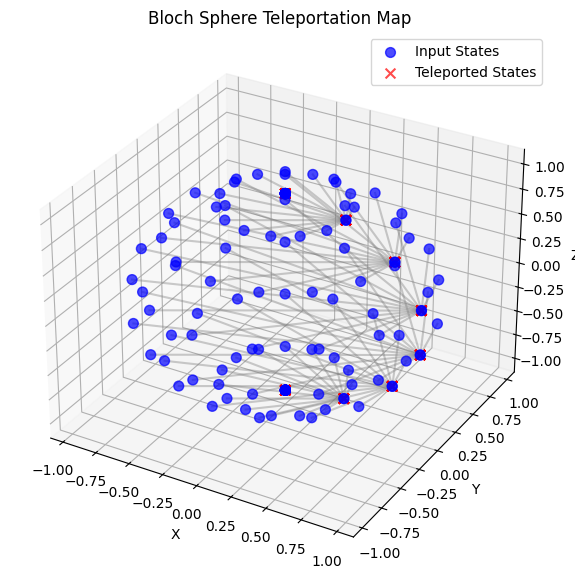

In [85]:
input_vectors, output_vectors = run_bloch_teleportation_map(noise_prob=0)

print(f"Number of input states: {len(input_vectors)}")
print(f"Number of teleported states: {len(output_vectors)}")

plot_bloch_teleportation_map(input_vectors, output_vectors)

## Continuous-Variable (CV) Teleportation

* This analyzes CV teleportation using two-mode squeezed states.
* Fidelity depends on squeezing parameter r.


In [86]:
from qutip import *

In [87]:
def cv_fidelity(r):
    # Analytical fidelity for coherent-state CV teleportation
    return 1 / (1 + np.exp(-2*r))

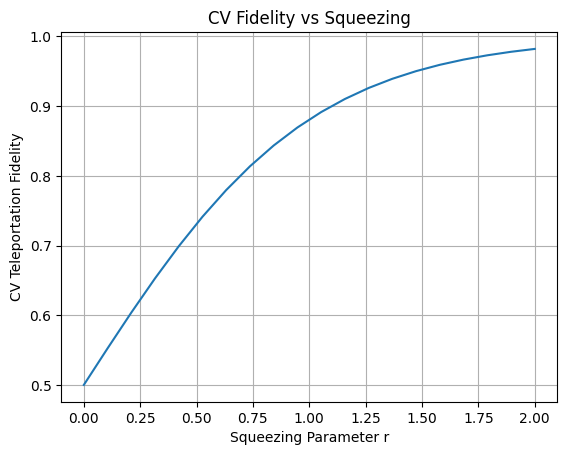

In [88]:
r_values = np.linspace(0, 2, 20)
fidelities_cv = [cv_fidelity(r) for r in r_values]

plt.figure()
plt.plot(r_values, fidelities_cv)
plt.xlabel('Squeezing Parameter r')
plt.ylabel('CV Teleportation Fidelity')
plt.title('CV Fidelity vs Squeezing')
plt.grid(True)
plt.show()